In [1]:
import pandas as pd

df = pd.read_csv('/content/Mall_Customers.csv')
display(df.head())
display(df.info())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

In [2]:
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
from sklearn.cluster import AgglomerativeClustering

agg_single = AgglomerativeClustering(n_clusters=5, linkage='single')
agg_complete = AgglomerativeClustering(n_clusters=5, linkage='complete')
agg_average = AgglomerativeClustering(n_clusters=5, linkage='average')

labels_single = agg_single.fit_predict(X_scaled)
labels_complete = agg_complete.fit_predict(X_scaled)
labels_average = agg_average.fit_predict(X_scaled)

In [8]:
from sklearn.cluster import KMeans
import numpy as np

def divisive_clustering(X, n_clusters):
    """
    Basic implementation of divisive clustering using K-Means for splitting.

    Args:
        X (np.ndarray): The input data.
        n_clusters (int): The desired number of clusters.

    Returns:
        np.ndarray: The cluster labels for each data point.
    """
    # Start with all data points in a single cluster
    labels = np.zeros(X.shape[0], dtype=int)
    current_clusters = [np.arange(X.shape[0])]

    # Keep splitting until the desired number of clusters is reached
    while len(current_clusters) < n_clusters:
        # Find the cluster to split (e.g., the one with the largest variance)
        largest_cluster_index = -1
        max_variance = -1
        for i, cluster_indices in enumerate(current_clusters):
            if len(cluster_indices) > 1:  # Only split clusters with more than one point
                cluster_data = X[cluster_indices]
                variance = np.sum(np.var(cluster_data, axis=0))
                if variance > max_variance:
                    max_variance = variance
                    largest_cluster_index = i

        # If no splittable cluster is found, break
        if largest_cluster_index == -1:
            break

        # Split the chosen cluster using K-Means (k=2)
        cluster_to_split_indices = current_clusters.pop(largest_cluster_index)
        cluster_to_split_data = X[cluster_to_split_indices]

        if len(cluster_to_split_data) > 1:
            kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
            kmeans_labels = kmeans.fit_predict(cluster_to_split_data)

            # Assign new labels to the points in the split cluster
            new_label_1 = max(labels) + 1
            new_label_2 = max(labels) + 2 if len(current_clusters) + 2 <= n_clusters else max(labels) + 1 # Ensure we don't exceed n_clusters

            cluster_1_indices = cluster_to_split_indices[kmeans_labels == 0]
            cluster_2_indices = cluster_to_split_indices[kmeans_labels == 1]

            labels[cluster_1_indices] = new_label_1
            labels[cluster_2_indices] = new_label_2

            # Add the new clusters to the list
            current_clusters.append(cluster_1_indices)
            current_clusters.append(cluster_2_indices)
        else:
             # If the cluster has only one point, add it back and stop trying to split it
            current_clusters.append(cluster_to_split_indices)


    # Re-label clusters to be sequential starting from 0
    unique_labels = np.unique(labels)
    label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
    labels_divisive = np.array([label_mapping[label] for label in labels])


    return labels_divisive

# Apply the divisive clustering algorithm
n_clusters = 5 # To match the agglomerative clustering
labels_divisive = divisive_clustering(X_scaled, n_clusters)

print("Divisive clustering labels:")
print(labels_divisive)

Divisive clustering labels:
[1 1 3 1 1 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 4 1 3 1 3 1 4 1 1 1 4 1 1 4 4 4 4 4 1 4 4 1 4 4 4 1 4 4 1 1 4 4 4 4
 4 1 4 4 1 4 4 1 4 4 1 4 4 1 1 4 4 1 4 4 1 1 4 1 4 1 1 4 4 1 4 1 4 4 4 4 4
 1 4 1 1 1 4 4 4 4 1 0 2 2 1 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


In [9]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate Silhouette scores
silhouette_single = silhouette_score(X_scaled, labels_single)
silhouette_complete = silhouette_score(X_scaled, labels_complete)
silhouette_average = silhouette_score(X_scaled, labels_average)
silhouette_divisive = silhouette_score(X_scaled, labels_divisive)

# Calculate Davies-Bouldin indices
davies_bouldin_single = davies_bouldin_score(X_scaled, labels_single)
davies_bouldin_complete = davies_bouldin_score(X_scaled, labels_complete)
davies_bouldin_average = davies_bouldin_score(X_scaled, labels_average)
davies_bouldin_divisive = davies_bouldin_score(X_scaled, labels_divisive)

# Print the scores
print(f"Silhouette Score (Single Linkage): {silhouette_single}")
print(f"Davies-Bouldin Index (Single Linkage): {davies_bouldin_single}")
print(f"Silhouette Score (Complete Linkage): {silhouette_complete}")
print(f"Davies-Bouldin Index (Complete Linkage): {davies_bouldin_complete}")
print(f"Silhouette Score (Average Linkage): {silhouette_average}")
print(f"Davies-Bouldin Index (Average Linkage): {davies_bouldin_average}")
print(f"Silhouette Score (Divisive Clustering): {silhouette_divisive}")
print(f"Davies-Bouldin Index (Divisive Clustering): {davies_bouldin_divisive}")

Silhouette Score (Single Linkage): 0.0030237255251292527
Davies-Bouldin Index (Single Linkage): 0.6287767234229444
Silhouette Score (Complete Linkage): 0.3999821356530837
Davies-Bouldin Index (Complete Linkage): 0.8847668365863901
Silhouette Score (Average Linkage): 0.40956924875250705
Davies-Bouldin Index (Average Linkage): 0.9202868175797428
Silhouette Score (Divisive Clustering): 0.41450839662773104
Davies-Bouldin Index (Divisive Clustering): 0.8870966339630033


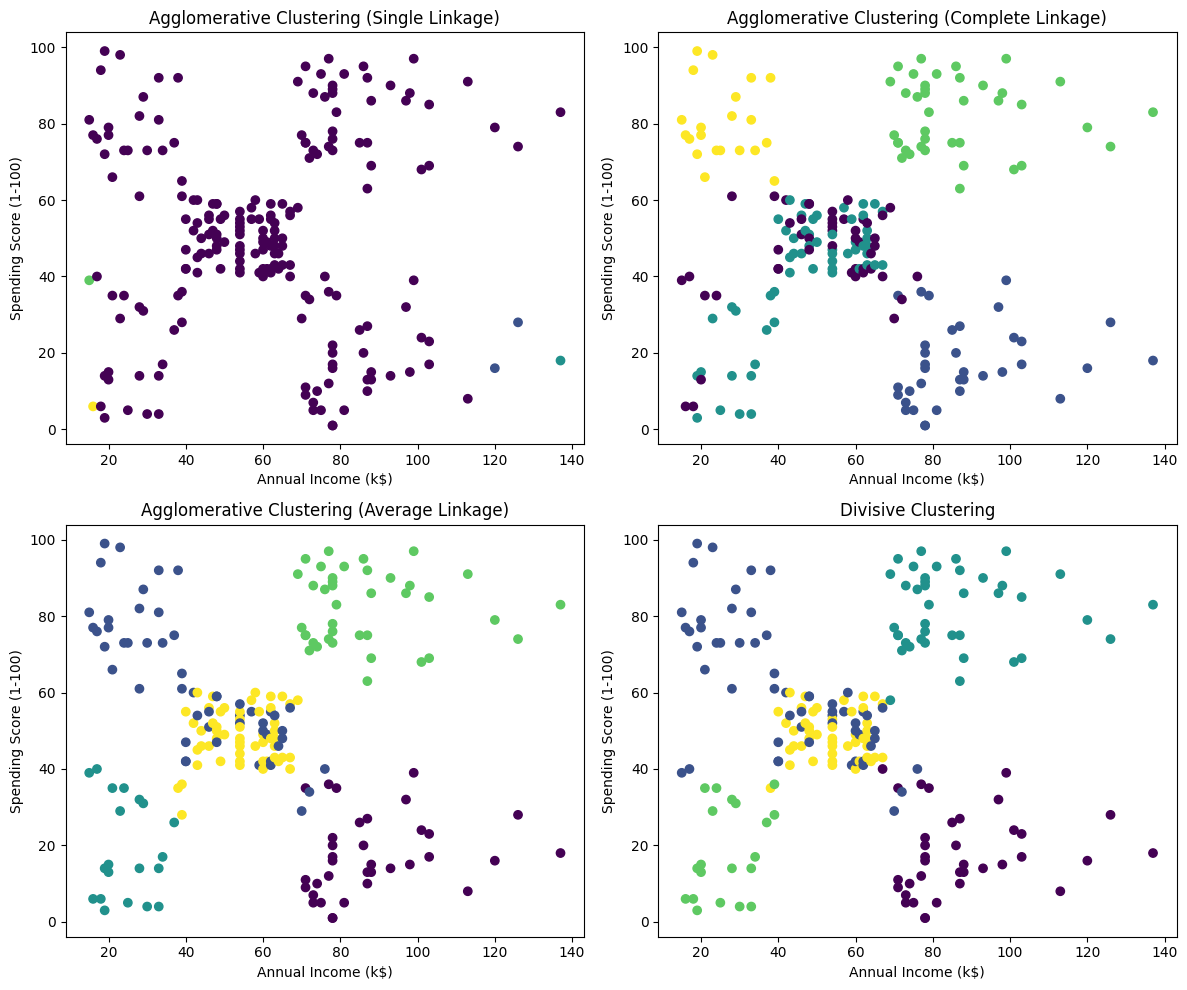

In [11]:
import matplotlib.pyplot as plt

# Add cluster labels to the original DataFrame
df['labels_single'] = labels_single
df['labels_complete'] = labels_complete
df['labels_average'] = labels_average
df['labels_divisive'] = labels_divisive

# Choose features for visualization
x_feature = 'Annual Income (k$)'
y_feature = 'Spending Score (1-100)'

# Create scatter plots for each clustering method
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Single Linkage
axes[0, 0].scatter(df[x_feature], df[y_feature], c=df['labels_single'], cmap='viridis')
axes[0, 0].set_title('Agglomerative Clustering (Single Linkage)')
axes[0, 0].set_xlabel(x_feature)
axes[0, 0].set_ylabel(y_feature)

# Complete Linkage
axes[0, 1].scatter(df[x_feature], df[y_feature], c=df['labels_complete'], cmap='viridis')
axes[0, 1].set_title('Agglomerative Clustering (Complete Linkage)')
axes[0, 1].set_xlabel(x_feature)
axes[0, 1].set_ylabel(y_feature)

# Average Linkage
axes[1, 0].scatter(df[x_feature], df[y_feature], c=df['labels_average'], cmap='viridis')
axes[1, 0].set_title('Agglomerative Clustering (Average Linkage)')
axes[1, 0].set_xlabel(x_feature)
axes[1, 0].set_ylabel(y_feature)

# Divisive Clustering
axes[1, 1].scatter(df[x_feature], df[y_feature], c=df['labels_divisive'], cmap='viridis')
axes[1, 1].set_title('Divisive Clustering')
axes[1, 1].set_xlabel(x_feature)
axes[1, 1].set_ylabel(y_feature)

plt.tight_layout()
plt.show()

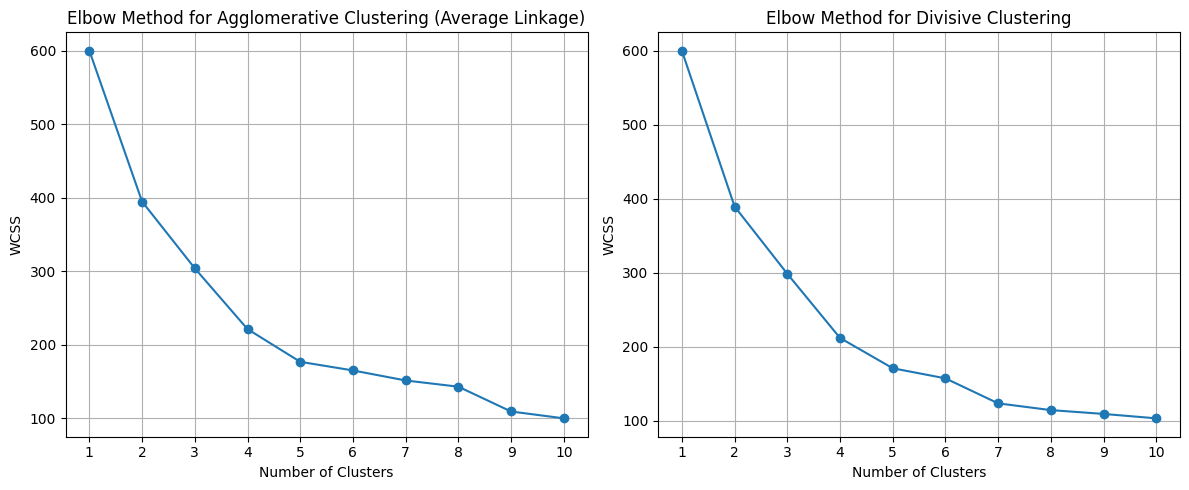

In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Function to calculate WCSS for Agglomerative Clustering
def calculate_wcss_agglomerative(X, max_clusters):
    wcss = []
    for i in range(1, max_clusters + 1):
        # Using Average linkage as it performed relatively well
        agg = AgglomerativeClustering(n_clusters=i, linkage='average')
        agg.fit(X)
        labels = agg.labels_
        # Calculate WCSS: sum of squared distances of samples to their closest cluster center
        # Since Agglomerative doesn't have explicit centers, we can use the mean of each cluster
        current_wcss = 0
        for cluster_label in np.unique(labels):
            cluster_points = X[labels == cluster_label]
            if len(cluster_points) > 0:
                cluster_center = np.mean(cluster_points, axis=0)
                current_wcss += np.sum((cluster_points - cluster_center) ** 2)
        wcss.append(current_wcss)
    return wcss

# Function to calculate WCSS for the custom Divisive Clustering
def calculate_wcss_divisive(X, max_clusters):
    wcss = []
    for i in range(1, max_clusters + 1):
        # Use the previously defined divisive clustering function
        labels = divisive_clustering(X, i)
        # Calculate WCSS based on cluster means
        current_wcss = 0
        for cluster_label in np.unique(labels):
            cluster_points = X[labels == cluster_label]
            if len(cluster_points) > 0:
                cluster_center = np.mean(cluster_points, axis=0)
                current_wcss += np.sum((cluster_points - cluster_center) ** 2)
        wcss.append(current_wcss)
    return wcss


# Define the range of clusters to test
max_clusters = 10

# Calculate WCSS for Agglomerative Clustering (Average Linkage)
wcss_agglomerative = calculate_wcss_agglomerative(X_scaled, max_clusters)

# Calculate WCSS for Divisive Clustering
wcss_divisive = calculate_wcss_divisive(X_scaled, max_clusters)


# Plot the Elbow Method results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, max_clusters + 1), wcss_agglomerative, marker='o')
plt.title('Elbow Method for Agglomerative Clustering (Average Linkage)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, max_clusters + 1), wcss_divisive, marker='o')
plt.title('Elbow Method for Divisive Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)

plt.tight_layout()
plt.show()

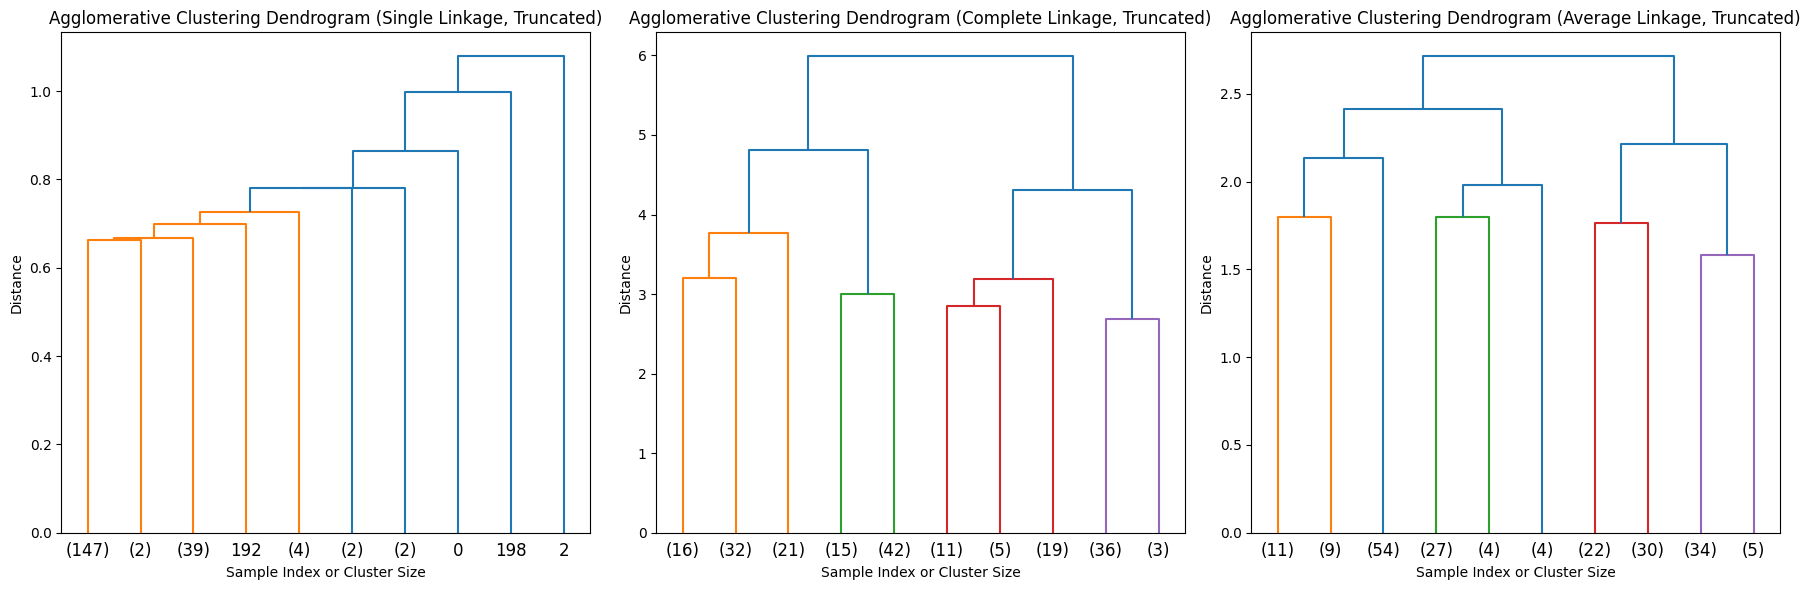

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate the linkage matrix for each method
linked_single = linkage(X_scaled, 'single')
linked_complete = linkage(X_scaled, 'complete')
linked_average = linkage(X_scaled, 'average')

# Plot the dendrograms
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
# Truncate the dendrogram to show only the last p merges (number of clusters - 1)
dendrogram(linked_single, orientation='top', distance_sort='descending', show_leaf_counts=True, p=10, truncate_mode='lastp')
plt.title('Agglomerative Clustering Dendrogram (Single Linkage, Truncated)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')

plt.subplot(1, 3, 2)
dendrogram(linked_complete, orientation='top', distance_sort='descending', show_leaf_counts=True, p=10, truncate_mode='lastp')
plt.title('Agglomerative Clustering Dendrogram (Complete Linkage, Truncated)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')

plt.subplot(1, 3, 3)
dendrogram(linked_average, orientation='top', distance_sort='descending', show_leaf_counts=True, p=10, truncate_mode='lastp')
plt.title('Agglomerative Clustering Dendrogram (Average Linkage, Truncated)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')

plt.tight_layout()
plt.show()